In [4]:
import joblib
import pandas as pd
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from src.features.engineering import engineer_features
from src.config import TARGET_COLUMN, N_SPLITS, RANDOM_STATE
MODEL_PATH = "../models/spaceship_titanic_catboost.joblib"

model = joblib.load(MODEL_PATH)

In [5]:
train_df = pd.read_csv("../data/raw/train.csv")

X = train_df.drop(columns=[TARGET_COLUMN])
y = train_df[TARGET_COLUMN]

X = engineer_features(X)

X = X.drop(columns=["PassengerId", "Name", "Cabin"])
y_pred = model.predict(X)

print("Accuracy:", accuracy_score(y, y_pred))

Accuracy: 0.8360750028758771


In [6]:
errors = X.copy()

errors["actual"] = y.values
errors["predicted"] = y_pred

errors["correct"] = errors["actual"] == errors["predicted"]
errors 

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalSpend,HasSpentMoney,GroupSize,IsAlone,Deck,CabinSide,actual,predicted,correct
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,0.0,False,1,True,B,P,False,True,False
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,736.0,True,1,True,F,S,True,False,False
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,10383.0,True,2,False,A,S,False,False,True
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,5176.0,True,2,False,A,S,False,False,True
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,1091.0,True,1,True,F,S,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,Europa,False,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,8536.0,True,1,True,A,P,False,False,True
8689,Earth,True,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,0.0,False,1,True,G,S,False,True,False
8690,Earth,False,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,1873.0,True,1,True,G,S,True,True,True
8691,Europa,False,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,4637.0,True,2,False,E,S,False,False,True


In [7]:
errors["correct"].value_counts()
print("Correct:", errors["correct"].sum())
print("Errors:", (~errors["correct"]).sum())

Correct: 7268
Errors: 1425


In [9]:
false_positives = errors[
    (errors["actual"] == False)
    & (errors["predicted"] == True)
]

false_negatives = errors[
    (errors["actual"] == True)
    & (errors["predicted"] == False)
]
print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 802
False Negatives: 623


In [10]:
cryosleep_analysis = (
    errors
    .groupby("CryoSleep")["correct"]
    .agg(
        total="count",
        errors=lambda x: (~x).sum(),
        accuracy="mean",
    )
)

cryosleep_analysis["error_rate"] = (
    1 - cryosleep_analysis["accuracy"]
)

cryosleep_analysis

,total,errors,accuracy,error_rate
CryoSleep,,,,
False,5439,883,0.837654,0.162346
True,3037,512,0.831413,0.168587


In [11]:
vip_analysis = (
    errors
    .groupby("VIP")["correct"]
    .agg(
        total="count",
        errors=lambda x: (~x).sum(),
        accuracy="mean",
    )
)

vip_analysis["error_rate"] = (
    1 - vip_analysis["accuracy"]
)

vip_analysis

,total,errors,accuracy,error_rate
VIP,,,,
False,8291,1365,0.835364,0.164636
True,199,19,0.904523,0.095477


In [12]:
homeplanet_analysis = (
    errors
    .groupby("HomePlanet")["correct"]
    .agg(
        total="count",
        errors=lambda x: (~x).sum(),
        accuracy="mean",
    )
)

homeplanet_analysis["error_rate"] = (
    1 - homeplanet_analysis["accuracy"]
)

homeplanet_analysis

,total,errors,accuracy,error_rate
HomePlanet,,,,
Earth,4602,1105,0.759887,0.240113
Europa,2131,103,0.951666,0.048334
Mars,1759,179,0.898238,0.101762


In [13]:
earth = errors[errors["HomePlanet"] == "Earth"].copy()

earth["error"] = ~earth["correct"]

earth.groupby("error").size()

error
False    3497
True     1105
dtype: int64

In [16]:
categorical_rows = []

for feature in [
    "CryoSleep",
    "VIP",
    "Deck",
    "CabinSide",
    "Destination",
]:
    table = pd.crosstab(
        earth[feature],
        earth["error"],
        normalize="index",
    )

    for value in table.index:
        categorical_rows.append({
            "Feature": feature,
            "Value": value,
            "Correct (%)": table.loc[value, False] * 100
            if False in table.columns else 0,
            "Error (%)": table.loc[value, True] * 100
            if True in table.columns else 0,
        })

categorical_analysis = pd.DataFrame(categorical_rows)

categorical_analysis.round(1)

,Feature,Value,Correct (%),Error (%)
0,CryoSleep,False,79.7,20.3
1,CryoSleep,True,67.4,32.6
2,VIP,False,76.2,23.8
3,Deck,E,82.3,17.7
4,Deck,F,80.4,19.6
5,Deck,G,72.4,27.6
6,CabinSide,P,76.5,23.5
7,CabinSide,S,75.7,24.3
8,Destination,55 Cancri e,78.3,21.7
9,Destination,PSO J318.5-22,72.8,27.2


In [17]:
numeric_analysis = (
    earth
    .groupby("error")[
        [
            "Age",
            "Spa",
            "VRDeck",
            "RoomService",
            "FoodCourt",
            "ShoppingMall",
            "TotalSpend",
            "GroupSize",
        ]
    ]
    .mean()
    .T
)

numeric_analysis

error,False,True
Age,26.372560,25.101758
Spa,168.881064,60.161887
VRDeck,160.387324,68.102493
RoomService,152.786445,86.529740
FoodCourt,140.431241,127.073148
ShoppingMall,142.381510,106.742537
TotalSpend,747.822705,437.613575
GroupSize,1.851587,2.014480


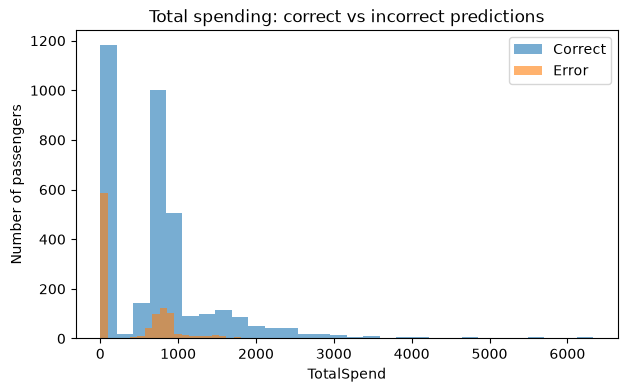

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

earth.loc[
    earth["correct"], "TotalSpend"
].plot(
    kind="hist",
    bins=30,
    alpha=0.6,
    label="Correct"
)

earth.loc[
    ~earth["correct"], "TotalSpend"
].plot(
    kind="hist",
    bins=30,
    alpha=0.6,
    label="Error"
)

plt.xlabel("TotalSpend")
plt.ylabel("Number of passengers")
plt.title("Total spending: correct vs incorrect predictions")
plt.legend()
plt.show()

Among Earth passengers, misclassified cases tend to have lower total spending than correctly classified cases. This suggests that low-spending passengers are a more challenging subgroup for the model.

The model particularly struggles with Earth passengers who have CryoSleep=True and, more generally, with passengers showing lower spending levels.